### Utility-Based Metrics
Standard metrics (MSE, MAE) ignore the importance of rare extreme delays.  
Following the imbalanced regression literature, we implement:

$$prec^\phi = \frac{\sum_i \phi(\hat{y}_i) \cdot \mathbf{1}[|y_i - \hat{y}_i| \leq \theta]}{\sum_i \phi(\hat{y}_i)}$$

$$rec^\phi = \frac{\sum_i \phi(y_i) \cdot \mathbf{1}[|y_i - \hat{y}_i| \leq \theta]}{\sum_i \phi(y_i)}$$

$$F_1^\phi = \frac{2 \cdot prec^\phi \cdot rec^\phi}{prec^\phi + rec^\phi}$$

Where $\theta$ is an acceptable error tolerance (default: 30 min).

In [1]:
import joblib

print("Loading data from disk...")
pipeline_inputs = joblib.load('pipeline_inputs.joblib')

datasets = pipeline_inputs['datasets']
X_test   = pipeline_inputs['X_test']
y_test   = pipeline_inputs['y_test']
phi_test = pipeline_inputs['phi_test']

print("Successfully loaded data!")

Loading data from disk...
Successfully loaded data!


### Model Definitions
- **Linear Regression** - baseline linear model  
- **SVR** - support vector regression (with scaling pipeline)  
- **SVR2** - approximate kernel SVR using Nyström feature map + SGD, trading exact kernel computation for linear scalability 
- **Random Forest** - ensemble of decision trees  
- **LightGBM** - gradient boosted trees (extra benchmark)

In [2]:
import pickle
import os

all_results = {}
all_models = {}

model_names = ['LinearRegression', 'SVR', 'SVR2', 'LightGBM', 'RandomForest']
import os
os.makedirs('results', exist_ok=True)

for model_name in model_names:
    results_file = f'results_{model_name}.pkl'
    models_file = f'{model_name}.pkl'
    
    if os.path.exists(results_file):
        with open(results_file, 'rb') as f:
            model_results = pickle.load(f)
        for strategy, metrics in model_results.items():
            all_results[(model_name, strategy)] = metrics
            
    if os.path.exists(models_file):
        with open(models_file, 'rb') as f:
            saved_models = pickle.load(f)
        for strategy, model in saved_models.items():
            all_models[(model_name, strategy)] = model

### Results Table

In [4]:
import pandas as pd


results_df = pd.DataFrame(all_results).T
results_df.index.names = ['Model', 'Strategy']
results_df = results_df[[
    'f1_phi', 'prec_phi', 'rec_phi',
    'Weighted_MAE', 'MAE', 'RMSE',
    'Tail_MAE', 'Tail_RMSE', 'tail_n'
]].sort_values('f1_phi', ascending=False)
results_df.round(4)

f1_phi  prec_phi  rec_phi  Weighted_MAE      MAE  \
Model            Strategy                                                       
SVR2             GaussNoise  0.8679    0.9006   0.8374       31.6959  25.3651   
LinearRegression Baseline    0.8544    0.8908   0.8210       30.0779  22.1970   
SVR              SMOTER      0.8447    0.8841   0.8086       29.6704  20.8228   
                 RU          0.8439    0.8869   0.8048       29.6809  20.5764   
                 RO          0.8420    0.8829   0.8047       29.6549  20.5361   
                 Baseline    0.8401    0.8853   0.7994       29.6381  20.1579   
                 WERCS       0.8399    0.8822   0.8014       29.6696  20.3327   
SVR2             Baseline    0.8383    0.8790   0.8011       29.6622  20.1622   
                 RO          0.8361    0.8753   0.8003       29.6617  20.1637   
                 SMOTER      0.8354    0.8745   0.7996       29.6587  20.1716   
                 RU          0.8348    0.8741   0.7990       29.6621  20.1619   
                 WERCS       0.8327    0.8704   0.7980       29.6620  20.1618   
LightGBM         GaussNoise  0.8138    0.8527   0.7783       26.4218  15.1463   
RandomForest     Baseline    0.8130    0.8204   0.8057       28.2936  20.7170   
LightGBM         RO          0.8103    0.8403   0.7823       26.1919  15.4680   
                 RU          0.8093    0.8496   0.7727       26.4627  14.7701   
                 SMOTER      0.8049    0.8476   0.7662       26.7121  14.6084   
                 Baseline    0.8021    0.8540   0.7561       27.0619  14.3900   
                 WERCS       0.7723    0.7641   0.7807       27.8378  20.2172   
SVR              GaussNoise  0.7408    0.7200   0.7628       31.8589  25.7414   
RandomForest     SMOTER      0.7362    0.7079   0.7668       30.1083  24.2152   
LinearRegression WERCS       0.7322    0.7053   0.7613       32.7866  27.3363   
RandomForest     RU          0.7031    0.6634   0.7480       31.2891  25.9626   
                 GaussNoise  0.6966    0.6555   0.7432       31.6723  26.3564   
LinearRegression RU          0.6869    0.6453   0.7342       33.1410  27.9244   
RandomForest     RO          0.6415    0.5849   0.7102       32.2824  27.6511   
LinearRegression RO          0.5425    0.4698   0.6418       34.6640  30.3240   
                 SMOTER      0.5333    0.4595   0.6352       34.6215  30.2622   
RandomForest     WERCS       0.3446    0.2680   0.4827       38.8187  36.5076   
LinearRegression GaussNoise  0.2020    0.1608   0.2715       42.7609  41.4811   

                                RMSE  Tail_MAE  Tail_RMSE    tail_n  
Model            Strategy                                            
SVR2             GaussNoise  51.0286  120.8419   178.9783  425862.0  
LinearRegression Baseline    50.7606  125.6312   182.2407  425862.0  
SVR              SMOTER      50.9108  129.1731   184.6393  425862.0  
                 RU          51.0105  130.3015   185.3636  425862.0  
                 RO          50.9978  130.3344   185.3924  425862.0  
                 Baseline    51.1507  131.7059   186.3100  425862.0  
                 WERCS       51.0924  131.1814   185.9453  425862.0  
SVR2             Baseline    51.1694  131.8097   186.3795  425862.0  
                 RO          51.1681  131.8010   186.3737  425862.0  
                 SMOTER      51.1609  131.7545   186.3425  425862.0  
                 RU          51.1694  131.8099   186.3797  425862.0  
                 WERCS       51.1695  131.8102   186.3799  425862.0  
LightGBM         GaussNoise  51.5688  133.7163   188.3512  425862.0  
RandomForest     Baseline    49.6922  118.6070   177.7250  425862.0  
LightGBM         RO          51.0744  130.5040   186.2923  425862.0  
                 RU          51.8221  135.5408   189.5561  425862.0  
                 SMOTER      52.1638  137.7168   190.8828  425862.0  
                 Baseline    52.7464  140.6318   192.8538  425862.0  
                 WERCS       50.1579

### F₁φ Heatmap - Model × Strategy

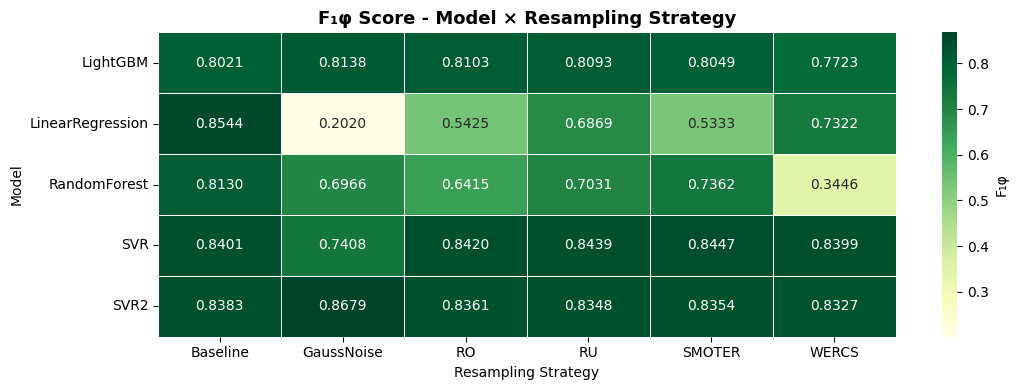

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
f1_pivot = results_df['f1_phi'].unstack(level='Strategy')

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(
    f1_pivot.astype(float),
    annot=True, fmt='.4f',
    cmap='YlGn',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'F₁φ'}
)
ax.set_title('F₁φ Score - Model × Resampling Strategy', fontsize=13, weight='bold')
ax.set_xlabel('Resampling Strategy')
ax.set_ylabel('Model')
plt.tight_layout()
plt.savefig('results/f1.png')

### Precision & Recall φ - Grouped Bar Chart

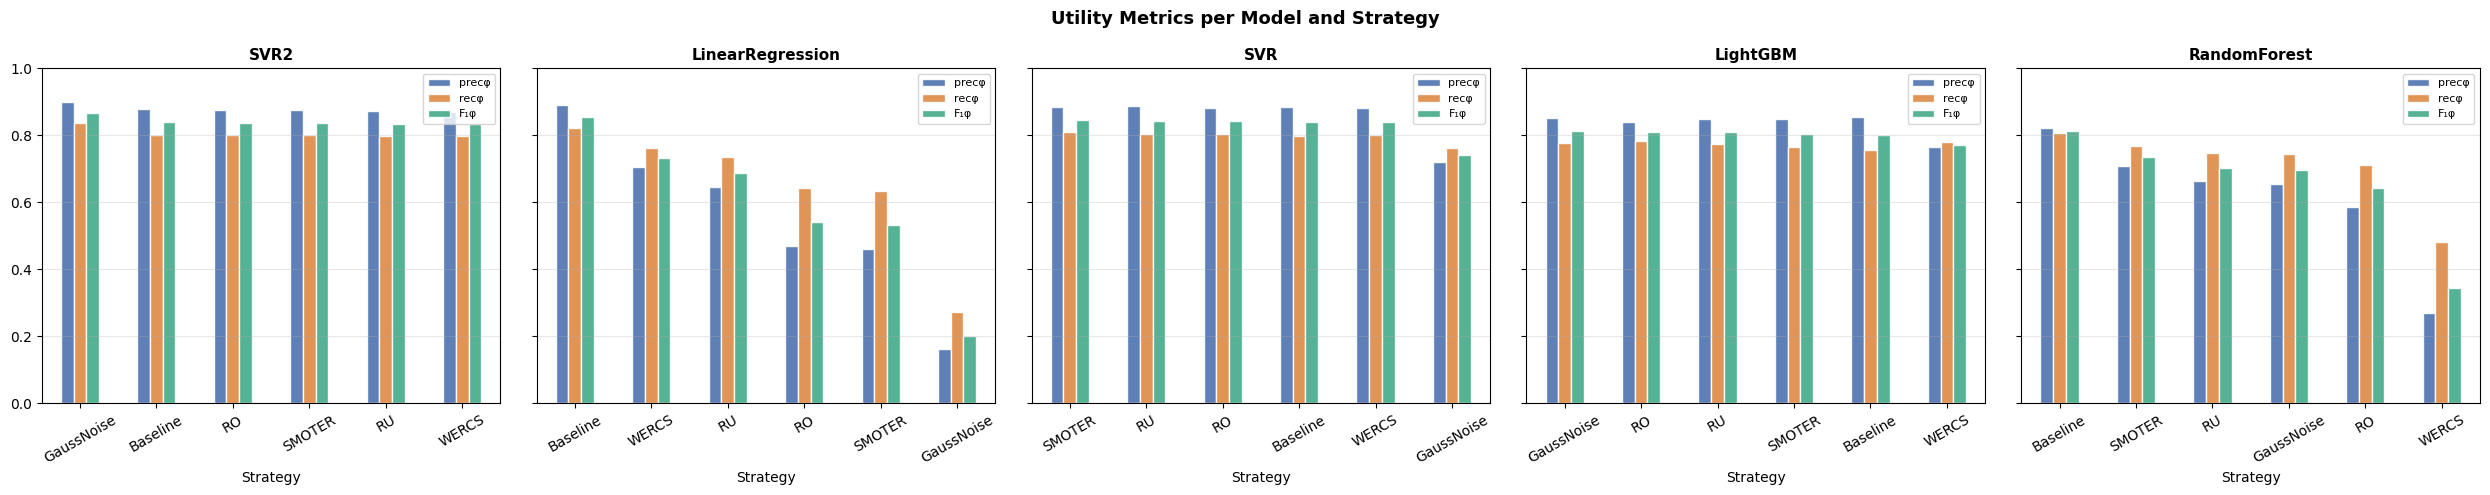

In [6]:
models_list     = results_df.index.get_level_values('Model').unique()
strategies_list = results_df.index.get_level_values('Strategy').unique()

fig, axes = plt.subplots(1, len(models_list), figsize=(5 * len(models_list), 5), sharey=True, squeeze=False)
axes = axes.flatten()

for ax, model_name in zip(axes, models_list):
    subset = results_df.loc[model_name][['prec_phi', 'rec_phi', 'f1_phi']]
    subset.plot.bar(ax=ax, color=['#4C72B0', '#dd8844', '#44aa88'],
                    edgecolor='white', alpha=0.9)
    ax.set_title(model_name, fontsize=11, weight='bold')
    ax.set_xlabel('Strategy')
    ax.tick_params(axis='x', rotation=30)
    ax.set_ylim(0, 1)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(['precφ', 'recφ', 'F₁φ'], fontsize=8)

plt.suptitle('Utility Metrics per Model and Strategy', fontsize=13, weight='bold')
plt.tight_layout()
plt.savefig('results/p&r.png')

### Overall MAE Comparison

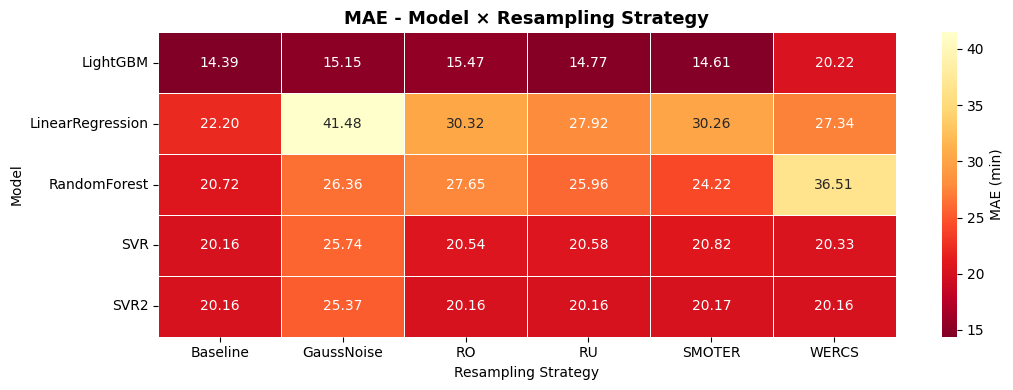

In [7]:
mae_pivot = results_df['MAE'].unstack(level='Strategy').astype(float)

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(
    mae_pivot,
    annot=True, fmt='.2f',
    cmap='YlOrRd_r',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'MAE (min)'}
)
ax.set_title('MAE - Model × Resampling Strategy', fontsize=13, weight='bold')
ax.set_xlabel('Resampling Strategy')
ax.set_ylabel('Model')
plt.tight_layout()
plt.savefig("results/mae.png")

### Best Combination & Key Findings

In [8]:
best_idx     = results_df['f1_phi'].idxmax()
best_metrics = results_df.loc[best_idx]

print('=== Best combination by F₁φ ===')
print(f'  Model    : {best_idx[0]}')
print(f'  Strategy : {best_idx[1]}')
print(f'  F₁φ      : {best_metrics["f1_phi"]:.4f}')
print(f'  precφ    : {best_metrics["prec_phi"]:.4f}')
print(f'  recφ     : {best_metrics["rec_phi"]:.4f}')
print(f'  MAE      : {best_metrics["MAE"]:.2f} min')
print(f'  RMSE     : {best_metrics["RMSE"]:.2f} min')
print()

rf_wercs_f1 = results_df.loc[('RandomForest', 'WERCS'), 'f1_phi']
print(f'RandomForest + WERCS F₁φ : {rf_wercs_f1:.4f}')
print(f'Hypothesis confirmed      : {best_idx == ("RandomForest", "WERCS")}')
print()

print('=== Best strategy per model (by F₁φ) ===')
for model_name in models_list:
    best_strat = results_df.loc[model_name, 'f1_phi'].idxmax()
    best_f1    = results_df.loc[(model_name, best_strat), 'f1_phi']
    print(f'  {model_name:<20}: {best_strat:<12}  F₁φ={best_f1:.4f}')

=== Best combination by F₁φ ===
  Model    : SVR2
  Strategy : GaussNoise
  F₁φ      : 0.8679
  precφ    : 0.9006
  recφ     : 0.8374
  MAE      : 25.37 min
  RMSE     : 51.03 min

RandomForest + WERCS F₁φ : 0.3446
Hypothesis confirmed      : False

=== Best strategy per model (by F₁φ) ===
  SVR2                : GaussNoise    F₁φ=0.8679
  LinearRegression    : Baseline      F₁φ=0.8544
  SVR                 : SMOTER        F₁φ=0.8447
  LightGBM            : GaussNoise    F₁φ=0.8138
  RandomForest        : Baseline      F₁φ=0.8130


### Feature Importance - Random Forest + WERCS

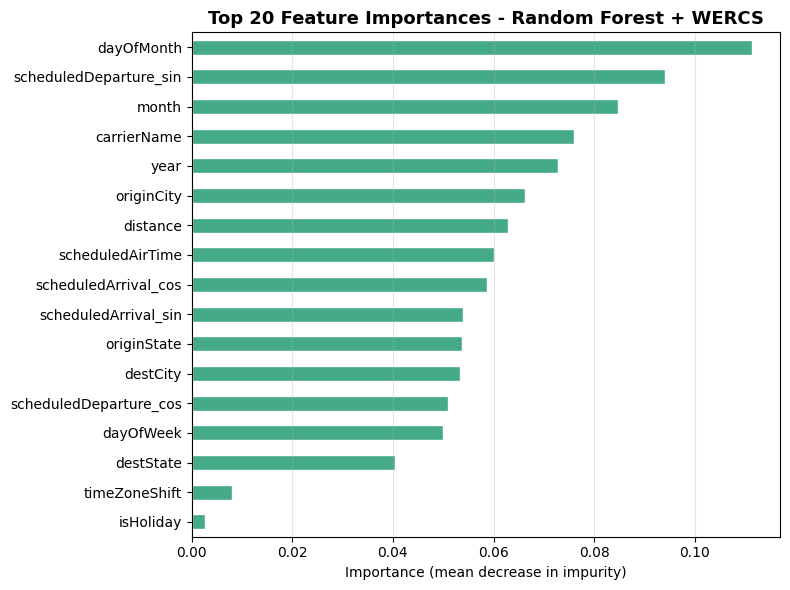

In [10]:
rf_wercs = all_models[('RandomForest', 'WERCS')]

fi = (
    pd.Series(rf_wercs.feature_importances_, index=X_test.columns)
    .sort_values(ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(8, 6))
fi.sort_values().plot.barh(ax=ax, color='#44aa88', edgecolor='white')
ax.set_title('Top 20 Feature Importances - Random Forest + WERCS', fontsize=13, weight='bold')
ax.set_xlabel('Importance (mean decrease in impurity)')
ax.grid(axis='x', alpha=0.35)
plt.tight_layout()
plt.savefig("results/fi_wercs_RF.png")

### Residual Distributions - Best Model per Strategy

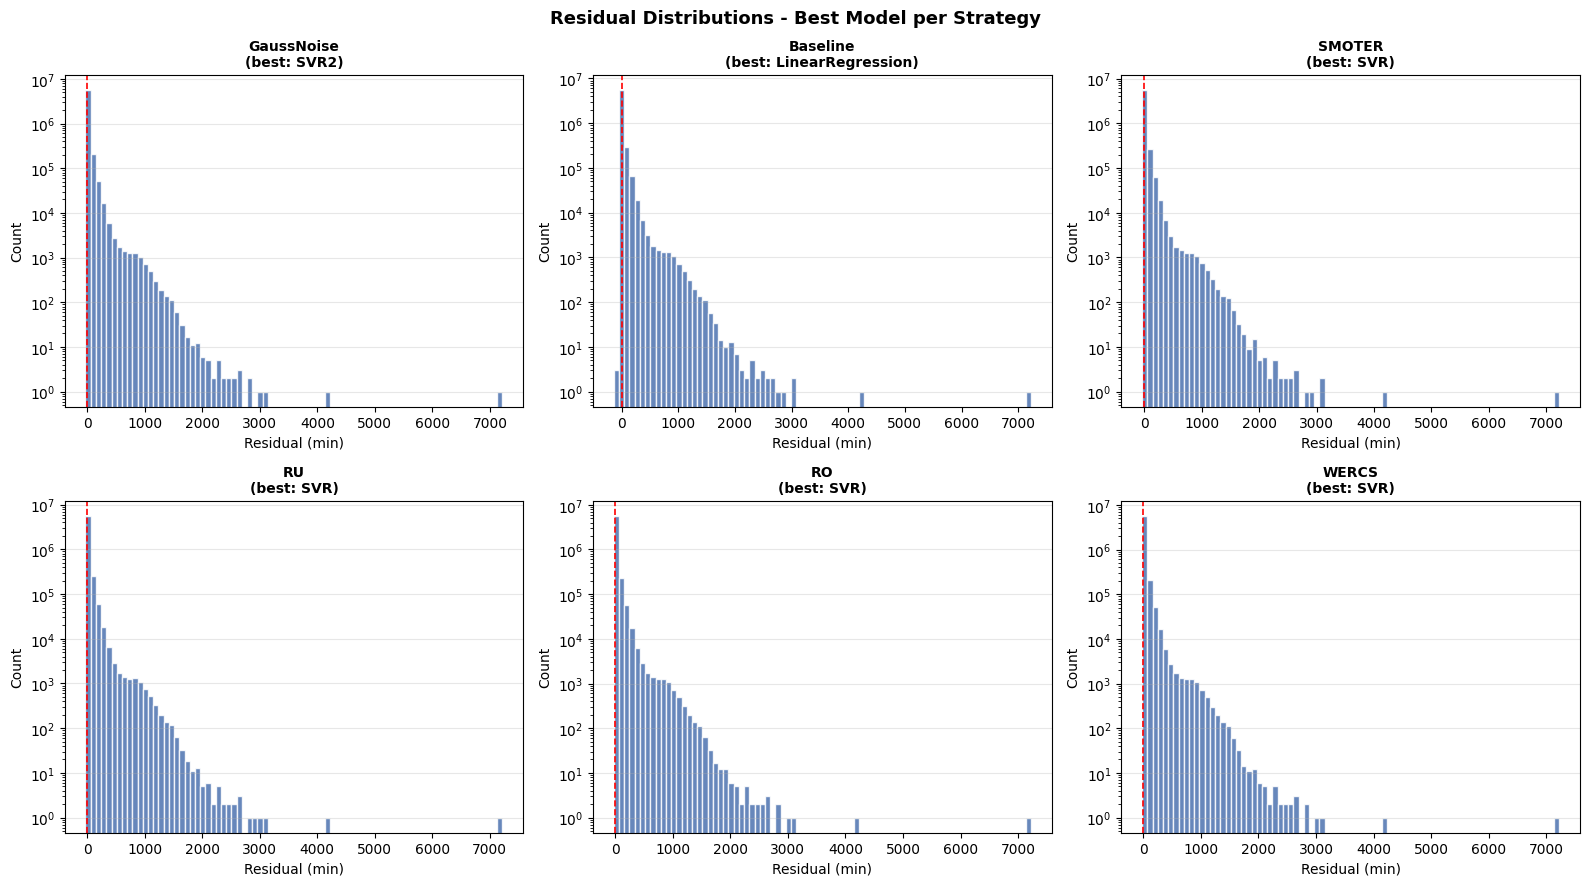

In [11]:
import numpy as np

# For each strategy, show residuals of the model with highest F1phi
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, strategy in zip(axes, strategies_list):
    best_model_name = results_df.xs(strategy, level='Strategy')['f1_phi'].idxmax()
    model = all_models[(best_model_name, strategy)]
    preds = np.clip(model.predict(X_test), 0, None)
    resid = y_test - preds

    ax.hist(resid, bins=80, color='#4C72B0', edgecolor='white', alpha=0.85)
    ax.axvline(0, color='red', linewidth=1.2, linestyle='--')
    ax.set_title(f'{strategy}\n(best: {best_model_name})', fontsize=10, weight='bold')
    ax.set_xlabel('Residual (min)')
    ax.set_ylabel('Count')
    ax.set_yscale('log')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Residual Distributions - Best Model per Strategy', fontsize=13, weight='bold')
plt.tight_layout()
plt.savefig("results/residual_distribution.png")